In [37]:
!pip install pyvis

Загружено записей: 54848, полей: 25
Легитимных: 54131, Подозрительных: 717

Метки подозрительных транзакций:
label
F-Mule-With    717
Name: count, dtype: int64

Распределение транзакций по типам:
          Легитимные  Подозрительные  Итого
tx_type                                    
ArRC           28312               0  28312
Dt             12867               0  12867
Ind             8205               0   8205
Merchant         443               0    443
Wl              4304             717   5021
All            54131             717  54848


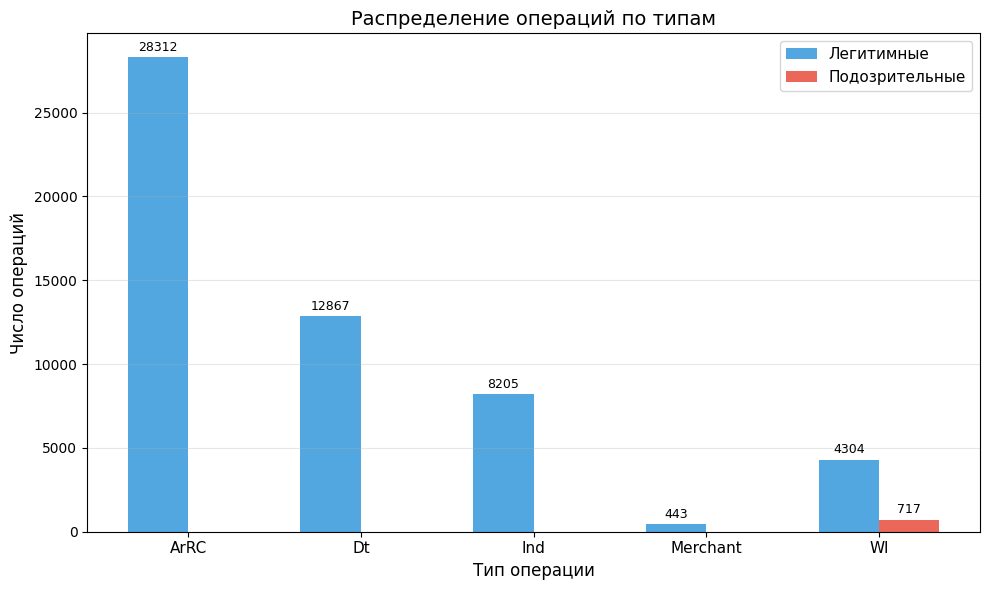

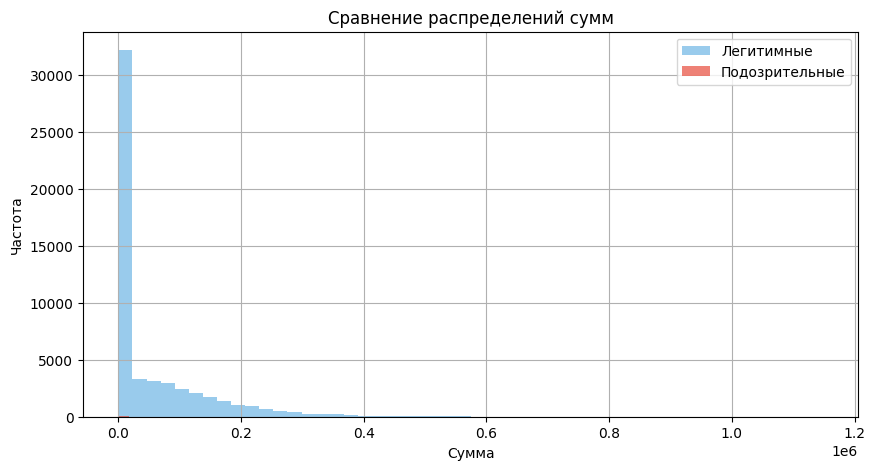

Легитимные суммы:
count    5.413100e+04
mean     5.569094e+04
std      8.772890e+04
min      3.200000e-01
25%      2.300590e+03
50%      6.715100e+03
75%      8.334121e+04
max      1.148351e+06
Name: amount, dtype: float64

Подозрительные суммы:
count      717.000000
mean     10591.167001
std       6973.084902
min         34.300000
25%       4829.930000
50%       9686.330000
75%      15130.780000
max      37560.370000
Name: amount, dtype: float64

Полный граф: 2009 вершин, 54848 дуг
Подозрительный граф: 10 вершин, 717 дуг
Компонент связности: 1
  #1: 10 вершин — {'PN_Ret6', 'PN_Ret5', 'PN_EU_0_260', 'PN_Ret4', 'PN_Ret3', 'PN_EU_1_328', 'PN_EU_0_955', 'PN_Ret1', 'PN_Ret2', 'PN_EU_0_1045'}

Анализ основного компонента (F-Mule-With)

Посредники (отправители): ['PN_EU_0_260' 'PN_EU_1_328' 'PN_EU_0_955' 'PN_EU_0_1045']
Агенты-ритейлеры (получатели): ['PN_Ret2' 'PN_Ret6' 'PN_Ret1' 'PN_Ret4' 'PN_Ret5' 'PN_Ret3']

Число посредников: 4
Число агентов: 6
Число подозрительных операций: 717
Суммарн

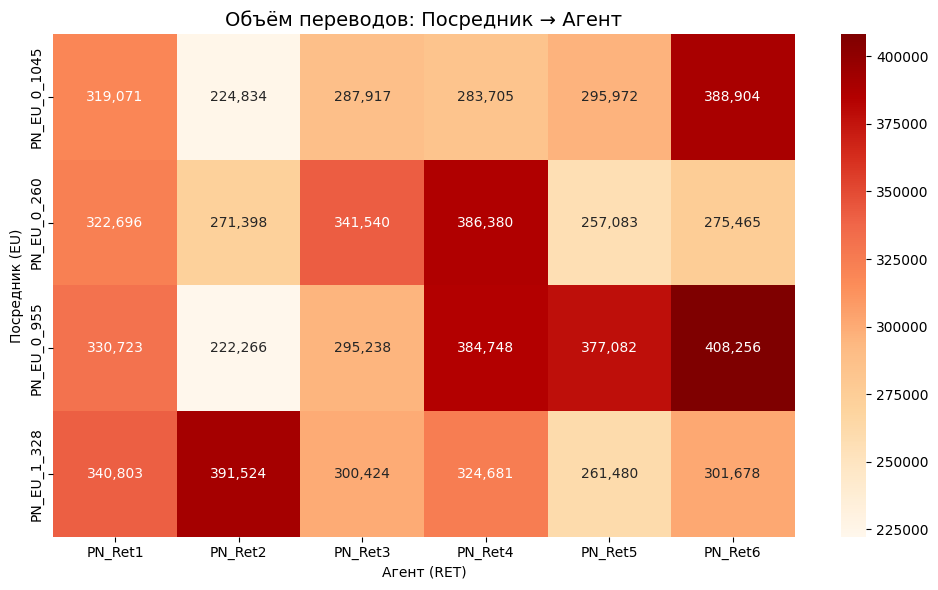

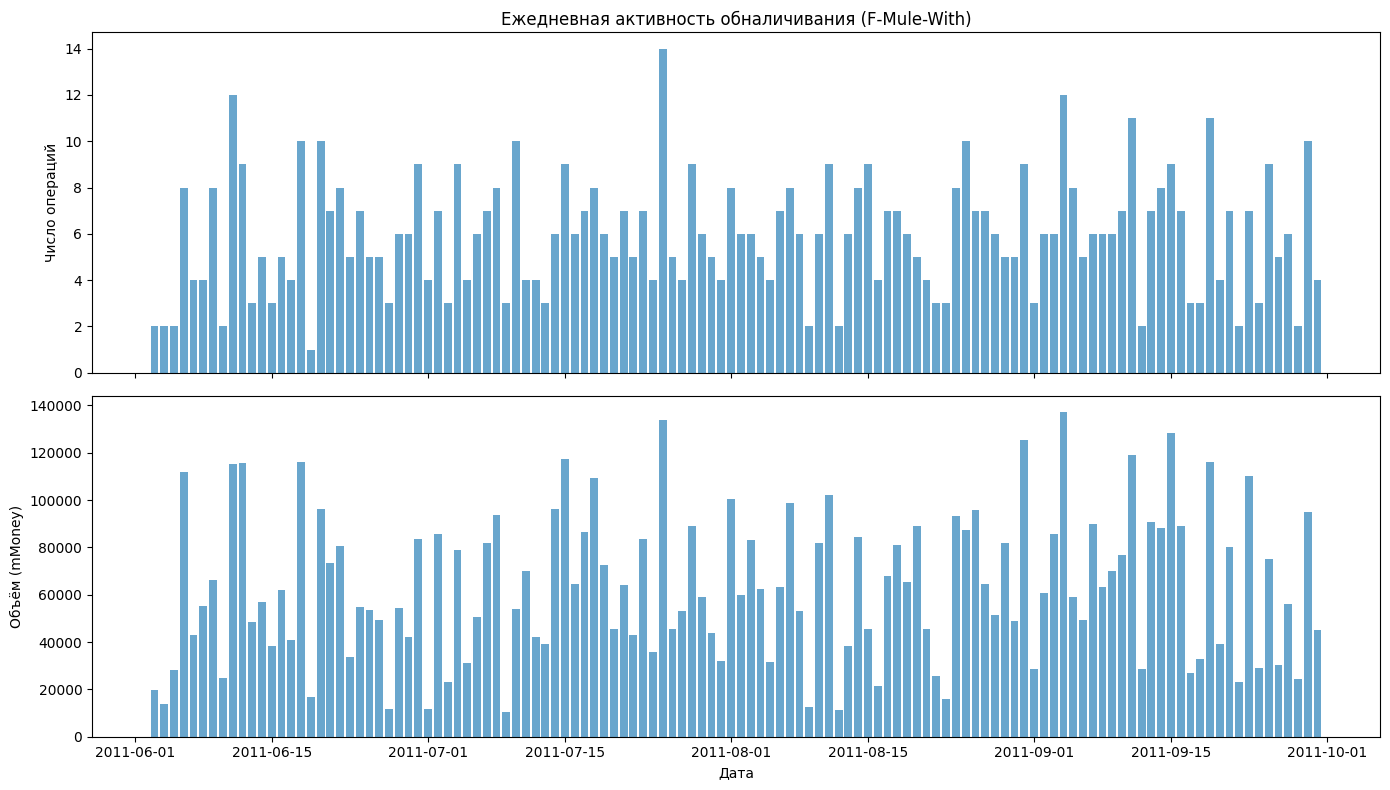

Источники средств посредников

 PN_EU_0_260 
  Входящих всего: 191
  Типы: {'Ind': 174, 'Dt': 17}
  C2C-переводов: 174 от 42 отправителей
  Сумма C2C: 2,229,478.29

 PN_EU_1_328 
  Входящих всего: 205
  Типы: {'Ind': 183, 'Dt': 22}
  C2C-переводов: 183 от 39 отправителей
  Сумма C2C: 1,939,990.14

 PN_EU_0_955 
  Входящих всего: 206
  Типы: {'Ind': 206}
  C2C-переводов: 206 от 42 отправителей
  Сумма C2C: 2,683,782.44

 PN_EU_0_1045 
  Входящих всего: 175
  Типы: {'Ind': 175}
  C2C-переводов: 175 от 39 отправителей
  Сумма C2C: 2,036,590.19

Всего уникальных отправителей: 46

Общие отправители
  PN_EU_0_260 ∩ PN_EU_1_328: 39 общих
  PN_EU_0_260 ∩ PN_EU_0_955: 39 общих
  PN_EU_0_260 ∩ PN_EU_0_1045: 38 общих
  PN_EU_1_328 ∩ PN_EU_0_955: 39 общих
  PN_EU_1_328 ∩ PN_EU_0_1045: 38 общих
  PN_EU_0_955 ∩ PN_EU_0_1045: 38 общих

Классификация отправителей

Полностью заражённые (100% → посредникам): 34
Частично скомпрометированные: 12

Первые 5 по объёму:
        user  ops_to_intermediaries  su

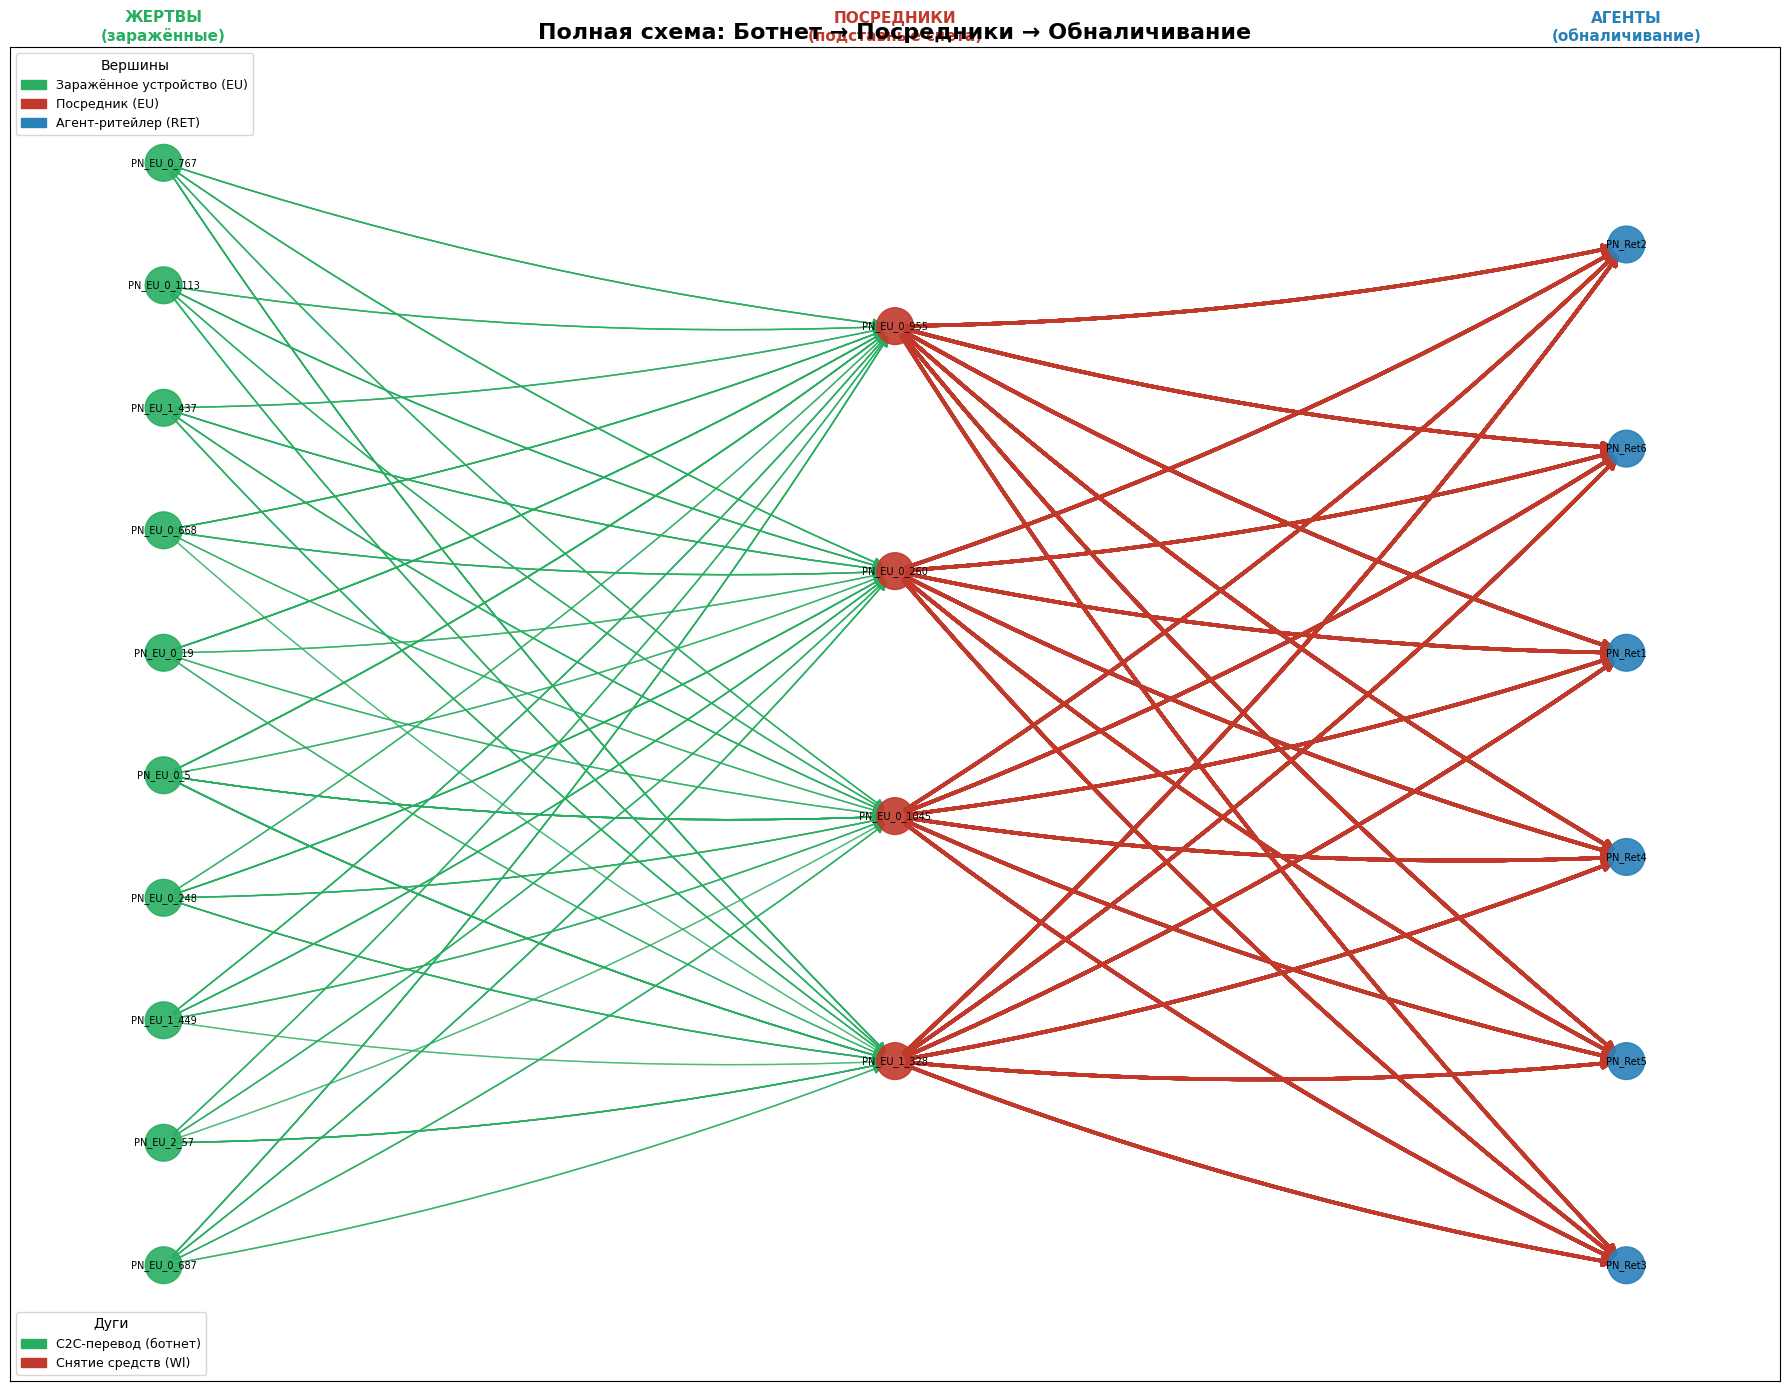

In [38]:
# Подключение библиотек
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.graph_objects as go
from pyvis.network import Network
import warnings
warnings.filterwarnings('ignore')

# Чтение данных из файла
fields = [
    'label', 'sender_id', 'receiver_id', 'sender_acc', 'receiver_acc',
    'amount', 'tx_type', 'status',
    'snd_bal_before', 'snd_bal_after', 'rcv_bal_before', 'rcv_bal_after',
    'flag1', 'flag2', 'unused1', 'unused2',
    'ts_sender', 'ts_receiver', 'sender_acc2',
    'svc1', 'svc2', 'tx_id', 'ts_tx',
    'snd_type', 'rcv_type'
]

raw = pd.read_csv('FinFraud_Labelled.csv', sep='|', header=None,
                   names=fields, skiprows=1)

print(f"Загружено записей: {raw.shape[0]}, полей: {raw.shape[1]}")
raw.head()

# Приведение типов и предобработка
numeric_cols = ['amount', 'snd_bal_before', 'snd_bal_after',
                'rcv_bal_before', 'rcv_bal_after']
for c in numeric_cols:
    raw[c] = pd.to_numeric(raw[c], errors='coerce')

time_cols = ['ts_sender', 'ts_receiver', 'ts_tx']
for c in time_cols:
    raw[c] = pd.to_datetime(raw[c], format='%d/%m/%Y %H:%M:%S', errors='coerce')

# Метка мошенничества
raw['fraud'] = raw['label'].fillna('').astype(str).apply(lambda x: x.startswith('F-'))

legitimate = raw[raw['fraud'] == False]
suspicious = raw[raw['fraud'] == True].copy()

print(f"Легитимных: {len(legitimate)}, Подозрительных: {len(suspicious)}")
print(f"\nМетки подозрительных транзакций:\n{suspicious['label'].value_counts()}")

# Общая статистика по типам операций
cross_tab = pd.crosstab(raw['tx_type'], raw['fraud'], margins=True)
cross_tab.columns = ['Легитимные', 'Подозрительные', 'Итого']
print("\nРаспределение транзакций по типам:")
print(cross_tab)

# Сравнение типов операций на одном графике
all_types = sorted(raw['tx_type'].dropna().unique())

legit_counts = legitimate['tx_type'].value_counts()
susp_counts = suspicious['tx_type'].value_counts()

legit_vals = [legit_counts.get(t, 0) for t in all_types]
susp_vals = [susp_counts.get(t, 0) for t in all_types]

x = np.arange(len(all_types))
bar_width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

bars1 = ax.bar(x - bar_width/2, legit_vals, bar_width,
               label='Легитимные', color='#3498db', alpha=0.85)
bars2 = ax.bar(x + bar_width/2, susp_vals, bar_width,
               label='Подозрительные', color='#e74c3c', alpha=0.85)

# Подписи значений над столбцами
for bar in bars1:
    h = bar.get_height()
    if h > 0:
        ax.text(bar.get_x() + bar.get_width()/2, h + 200,
                f'{int(h)}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    h = bar.get_height()
    if h > 0:
        ax.text(bar.get_x() + bar.get_width()/2, h + 200,
                f'{int(h)}', ha='center', va='bottom', fontsize=9)
ax.set_xlabel('Тип операции', fontsize=12)
ax.set_ylabel('Число операций', fontsize=12)
ax.set_title('Распределение операций по типам', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(all_types, fontsize=11)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Сравнение сумм
fig, ax = plt.subplots(figsize=(10, 5))
legitimate['amount'].dropna().hist(bins=50, alpha=0.5, label='Легитимные',
                                    color='#3498db', ax=ax)
suspicious['amount'].dropna().hist(bins=50, alpha=0.7, label='Подозрительные',
                                    color='#e74c3c', ax=ax)
ax.set_xlabel('Сумма')
ax.set_ylabel('Частота')
ax.set_title('Сравнение распределений сумм')
ax.legend()
plt.savefig('amounts_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("Легитимные суммы:")
print(legitimate['amount'].describe())
print("\nПодозрительные суммы:")
print(suspicious['amount'].describe())

# Формирование графа из таблицы транзакций
def create_graph(transactions):
    """Создаёт ориентированный мультиграф из DataFrame транзакций."""
    graph = nx.MultiDiGraph()
    for _, rec in transactions.iterrows():
        src = str(rec['sender_id'])
        dst = str(rec['receiver_id'])
        if src not in graph:
            graph.add_node(src, role=str(rec.get('snd_type', '?')))
        if dst not in graph:
            graph.add_node(dst, role=str(rec.get('rcv_type', '?')))
        graph.add_edge(src, dst,
                       amount=rec['amount'],
                       tx_type=str(rec['tx_type']),
                       label=str(rec['label']),
                       fraud=rec['fraud'],
                       status=str(rec['status']),
                       ts=rec['ts_tx'])
    return graph

# Построение графов
graph_full = create_graph(raw)
graph_susp = create_graph(suspicious)

print(f"\nПолный граф: {graph_full.number_of_nodes()} вершин, "
      f"{graph_full.number_of_edges()} дуг")
print(f"Подозрительный граф: {graph_susp.number_of_nodes()} вершин, "
      f"{graph_susp.number_of_edges()} дуг")

# Выделение компонент связности в подозрительном графе
undirected_susp = graph_susp.to_undirected()
components = sorted(nx.connected_components(undirected_susp),
                    key=len, reverse=True)

print(f"Компонент связности: {len(components)}")
for idx, c in enumerate(components):
    print(f"  #{idx+1}: {len(c)} вершин — {c}")

# Анализ главного компонента (F-Mule-With)
main_comp = components[0]
main_fraud = suspicious[
    (suspicious['sender_id'].astype(str).isin(main_comp)) |
    (suspicious['receiver_id'].astype(str).isin(main_comp))
]

intermediaries = main_fraud['sender_id'].unique()   # посредники
retailers = main_fraud['receiver_id'].unique()       # агенты

print("\nАнализ основного компонента (F-Mule-With)")
print(f"\nПосредники (отправители): {intermediaries}")
print(f"Агенты-ритейлеры (получатели): {retailers}")
print(f"\nЧисло посредников: {len(intermediaries)}")
print(f"Число агентов: {len(retailers)}")
print(f"Число подозрительных операций: {len(main_fraud)}")
print(f"Суммарный объём: {main_fraud['amount'].sum():,.2f}")
print(f"Средний чек: {main_fraud['amount'].mean():,.2f}")
print(f"Период: {main_fraud['ts_tx'].min()} — {main_fraud['ts_tx'].max()}")

# Активность каждого посредника
print("\nПо посредникам")
for person in intermediaries:
    subset = main_fraud[main_fraud['sender_id'] == person]
    print(f"  {person}: {len(subset)} операций, "
          f"сумма = {subset['amount'].sum():,.2f}, "
          f"средняя = {subset['amount'].mean():,.2f}")

# Активность по каждому агенту
print("\nПо агентам")
for agent in retailers:
    subset = main_fraud[main_fraud['receiver_id'] == agent]
    print(f"  {agent}: {len(subset)} операций, "
          f"сумма = {subset['amount'].sum():,.2f}")

# Тепловая карта: посредник × агент
pivot_table = main_fraud.groupby(
    ['sender_id', 'receiver_id']
)['amount'].sum().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(pivot_table, annot=True, fmt=',.0f', cmap='OrRd', ax=ax)
ax.set_title('Объём переводов: Посредник → Агент', fontsize=14)
ax.set_xlabel('Агент (RET)')
ax.set_ylabel('Посредник (EU)')
plt.tight_layout()
plt.savefig('intermediary_agent_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Ежедневная динамика подозрительной активности
daily = main_fraud.set_index('ts_tx').resample('D')['amount'].agg(
    ['sum', 'count']
)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
ax1.bar(daily.index, daily['count'], color='#2980b9', alpha=0.7)
ax1.set_ylabel('Число операций')
ax1.set_title('Ежедневная активность обналичивания (F-Mule-With)')

ax2.bar(daily.index, daily['sum'], color='#2980b9', alpha=0.7)
ax2.set_ylabel('Объём (mMoney)')
ax2.set_xlabel('Дата')

plt.tight_layout()
plt.savefig('daily_cashout.png', dpi=150, bbox_inches='tight')
plt.show()

# Исследование источников средств посредников
print("Источники средств посредников")

intermediary_list = list(intermediaries)
all_feeders = set()

for person in intermediary_list:
    inbound = raw[(raw['receiver_id'] == person)]
    inbound_c2c = inbound[inbound['tx_type'] == 'Ind']
    feeders = inbound_c2c['sender_id'].unique()
    all_feeders.update(feeders)

    print(f"\n {person} ")
    print(f"  Входящих всего: {len(inbound)}")
    print(f"  Типы: {inbound['tx_type'].value_counts().to_dict()}")
    print(f"  C2C-переводов: {len(inbound_c2c)} от {len(feeders)} отправителей")
    print(f"  Сумма C2C: {inbound_c2c['amount'].sum():,.2f}")

print(f"\nВсего уникальных отправителей: {len(all_feeders)}")

# Пересечения отправителей
print("\nОбщие отправители")
for i in range(len(intermediary_list)):
    for j in range(i + 1, len(intermediary_list)):
        p1, p2 = intermediary_list[i], intermediary_list[j]
        s1 = set(raw[(raw['receiver_id'] == p1) &
                      (raw['tx_type'] == 'Ind')]['sender_id'])
        s2 = set(raw[(raw['receiver_id'] == p2) &
                      (raw['tx_type'] == 'Ind')]['sender_id'])
        common = s1 & s2
        print(f"  {p1} ∩ {p2}: {len(common)} общих")

# Классификация отправителей
records = []
for feeder in all_feeders:
    sent_to_interm = raw[
        (raw['sender_id'] == feeder) &
        (raw['receiver_id'].isin(intermediary_list)) &
        (raw['tx_type'] == 'Ind')
    ]
    sent_total = raw[
        (raw['sender_id'] == feeder) &
        (raw['tx_type'] == 'Ind')
    ]
    n_interm = sent_to_interm['receiver_id'].nunique()
    records.append({
        'user': feeder,
        'ops_to_intermediaries': len(sent_to_interm),
        'sum_to_intermediaries': sent_to_interm['amount'].sum(),
        'ops_total': len(sent_total),
        'sum_total': sent_total['amount'].sum(),
        'intermediaries_count': n_interm,
        'share_pct': len(sent_to_interm) / max(len(sent_total), 1) * 100
    })

feeder_stats = pd.DataFrame(records).sort_values('sum_to_intermediaries',
                                                    ascending=False)

botnet_infected = feeder_stats[feeder_stats['share_pct'] == 100.0]
partially_compromised = feeder_stats[
    (feeder_stats['share_pct'] > 0) & (feeder_stats['share_pct'] < 100)
]

print("\nКлассификация отправителей")
print(f"\nПолностью заражённые (100% → посредникам): {len(botnet_infected)}")
print(f"Частично скомпрометированные: {len(partially_compromised)}")
print(f"\nПервые 5 по объёму:")
print(feeder_stats.head(5).to_string(index=False))

print(f"\nОтправлявшие всем 4 посредникам:")
to_all_four = feeder_stats[feeder_stats['intermediaries_count'] == 4]
print(f"{len(to_all_four)}")

# Трёхслойная визуализация схемы (matplotlib)
top_victims = list(botnet_infected.head(10)['user'].values)

# Данные: жертвы → посредники
flow_in = raw[
    (raw['sender_id'].isin(top_victims)) &
    (raw['receiver_id'].isin(intermediary_list)) &
    (raw['tx_type'] == 'Ind')
]
# Данные: посредники → агенты
flow_out = suspicious[suspicious['label'] == 'F-Mule-With']

combined = pd.concat([flow_in, flow_out])
g_combined = create_graph(combined)

# Переназначаем роли
for nd in g_combined.nodes():
    if nd in intermediary_list:
        g_combined.nodes[nd]['role'] = 'INTERMEDIARY'
    elif nd.startswith('PN_Ret'):
        g_combined.nodes[nd]['role'] = 'RETAILER'
    elif nd in list(all_feeders):
        g_combined.nodes[nd]['role'] = 'INFECTED'

# Позиции: три слоя
positions = {}
infected_nodes = [n for n in g_combined if
                  g_combined.nodes[n].get('role') == 'INFECTED']
interm_nodes = [n for n in g_combined if
                g_combined.nodes[n].get('role') == 'INTERMEDIARY']
retail_nodes = [n for n in g_combined if
                g_combined.nodes[n].get('role') == 'RETAILER']

for k, nd in enumerate(infected_nodes):
    positions[nd] = (0, -k * 1.5)
for k, nd in enumerate(interm_nodes):
    positions[nd] = (5, -k * 3 - 2)
for k, nd in enumerate(retail_nodes):
    positions[nd] = (10, -k * 2.5 - 1)

role_palette = {
    'INFECTED': '#27ae60',       # зелёный — жертвы
    'INTERMEDIARY': '#c0392b',   # бордовый — посредники
    'RETAILER': '#2980b9',       # синий — агенты
}

node_clrs = [role_palette.get(g_combined.nodes[n].get('role', ''), '#bdc3c7')
             for n in g_combined.nodes()]

edge_clrs = ['#c0392b' if d.get('fraud') else '#27ae60'
             for _, _, d in g_combined.edges(data=True)]
edge_w = [2.5 if d.get('fraud') else 1
          for _, _, d in g_combined.edges(data=True)]

fig, ax = plt.subplots(figsize=(18, 14))
nx.draw_networkx_nodes(g_combined, positions, node_color=node_clrs,
                       node_size=700, alpha=0.9, ax=ax)
nx.draw_networkx_labels(g_combined, positions, font_size=7, ax=ax)
nx.draw_networkx_edges(g_combined, positions, edge_color=edge_clrs,
                       width=edge_w, alpha=0.6, arrows=True,
                       arrowsize=15, ax=ax,
                       connectionstyle="arc3,rad=0.05")

node_legend = [
    mpatches.Patch(color='#27ae60', label='Заражённое устройство (EU)'),
    mpatches.Patch(color='#c0392b', label='Посредник (EU)'),
    mpatches.Patch(color='#2980b9', label='Агент-ритейлер (RET)'),
]
edge_legend = [
    mpatches.Patch(color='#27ae60', label='C2C-перевод (ботнет)'),
    mpatches.Patch(color='#c0392b', label='Снятие средств (Wl)'),
]
leg1 = ax.legend(handles=node_legend, title="Вершины",
                 loc='upper left', fontsize=9)
ax.add_artist(leg1)
ax.legend(handles=edge_legend, title="Дуги",
          loc='lower left', fontsize=9)

ax.set_title('Полная схема: Ботнет → Посредники → Обналичивание',
             fontsize=16, fontweight='bold')
ax.text(0, 1.5, 'ЖЕРТВЫ\n(заражённые)', ha='center',
        fontsize=11, color='#27ae60', fontweight='bold')
ax.text(5, 1.5, 'ПОСРЕДНИКИ\n(подставные счета)', ha='center',
        fontsize=11, color='#c0392b', fontweight='bold')
ax.text(10, 1.5, 'АГЕНТЫ\n(обналичивание)', ha='center',
        fontsize=11, color='#2980b9', fontweight='bold')

plt.tight_layout()
plt.show()

# Sankey с новыми цветами
# Агрегируем потоки: жертвы → посредники
agg_v2i = flow_in.groupby(['sender_id', 'receiver_id'])['amount'].sum().reset_index()
agg_v2i.columns = ['src', 'dst', 'vol']

# Агрегируем потоки: посредники → агенты
agg_i2r = flow_out.groupby(['sender_id', 'receiver_id'])['amount'].sum().reset_index()
agg_i2r.columns = ['src', 'dst', 'vol']

# Объединяем
all_flows = pd.concat([agg_v2i, agg_i2r])

# Уникальные узлы и их индексы
labels_sankey = list(set(all_flows['src'].tolist() + all_flows['dst'].tolist()))
label_map = {name: num for num, name in enumerate(labels_sankey)}

# Цвета узлов
sankey_node_colors = []
for lb in labels_sankey:
    if lb in intermediary_list:
        sankey_node_colors.append('#c0392b')
    elif lb.startswith('PN_Ret'):
        sankey_node_colors.append('#2980b9')
    else:
        sankey_node_colors.append('#27ae60')

# Цвета связей
sankey_link_colors = []
for _, r in all_flows.iterrows():
    if r['src'] in intermediary_list:
        sankey_link_colors.append('rgba(192,57,43,0.4)')
    else:
        sankey_link_colors.append('rgba(39,174,96,0.4)')

fig_sankey = go.Figure(go.Sankey(
    node=dict(pad=15, thickness=20,
              label=labels_sankey, color=sankey_node_colors),
    link=dict(
        source=[label_map[s] for s in all_flows['src']],
        target=[label_map[t] for t in all_flows['dst']],
        value=all_flows['vol'].tolist(),
        color=sankey_link_colors
    )
))
fig_sankey.update_layout(
    title="Потоки средств: Жертвы → Посредники → Агенты",
    font_size=10, width=1100, height=700
)
fig_sankey.show()

# Plotly: интерактивный граф подозрительных транзакций
def plotly_graph(G, heading="Граф"):
    simple = nx.Graph(G)
    layout = nx.spring_layout(simple, k=1.5, seed=7)

    ex, ey = [], []
    for u, v in simple.edges():
        x0, y0 = layout[u]
        x1, y1 = layout[v]
        ex += [x0, x1, None]
        ey += [y0, y1, None]

    edges_trace = go.Scatter(x=ex, y=ey,
                             line=dict(width=1, color='#aaa'),
                             hoverinfo='none', mode='lines')

    palette = {'EU': 'green', 'RET': 'orange', 'Mer': 'purple',
               'MNO': 'red', 'INTERMEDIARY': 'red', 'INFECTED': 'blue',
               'RETAILER': 'orange', '?': 'gray', 'nan': 'gray'}

    nx_, ny_, nt_, nc_ = [], [], [], []
    for nd in simple.nodes():
        x, y = layout[nd]
        nx_.append(x)
        ny_.append(y)
        r = G.nodes[nd].get('role', '?')
        nt_.append(f"{nd}<br>Role: {r}<br>Deg: {simple.degree(nd)}")
        nc_.append(palette.get(r, 'gray'))

    nodes_trace = go.Scatter(
        x=nx_, y=ny_, mode='markers+text',
        hoverinfo='text', hovertext=nt_,
        text=[n for n in simple.nodes()],
        textposition="top center", textfont=dict(size=7),
        marker=dict(size=12, color=nc_, line_width=2)
    )

    fig = go.Figure(
        data=[edges_trace, nodes_trace],
        layout=go.Layout(
            title=heading, showlegend=False, hovermode='closest',
            xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
            yaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
            width=900, height=700
        )
    )
    fig.show()

plotly_graph(graph_susp, heading="Подозрительные транзакции (Plotly)")
plotly_graph(g_combined, heading="Полная схема мошенничества (Plotly)")

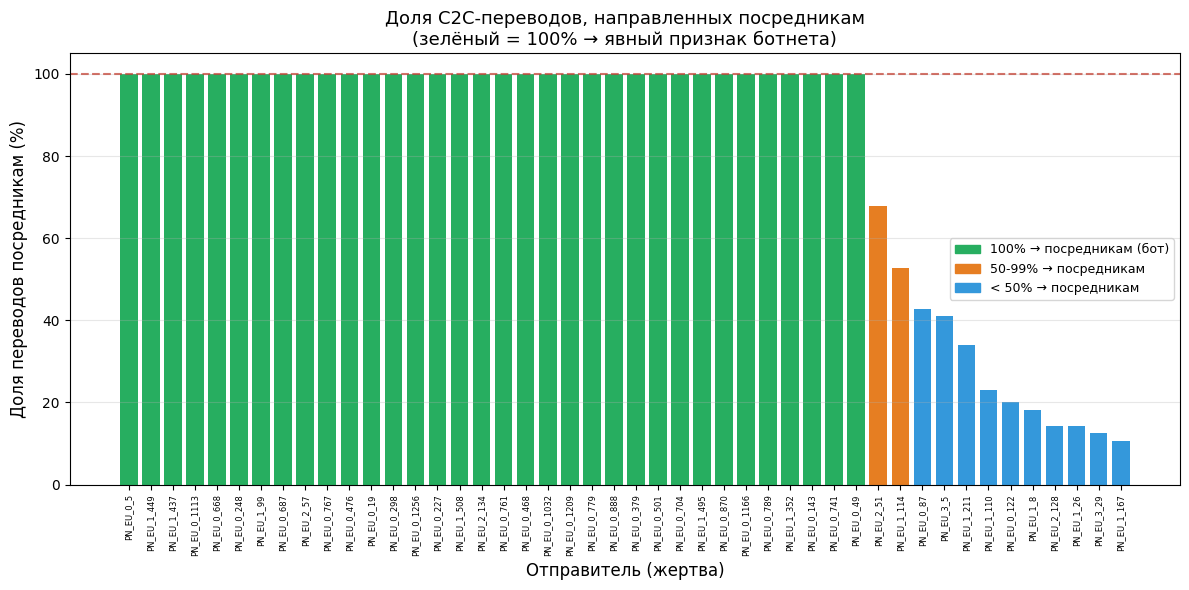

In [39]:
# Доказательство ботнета: доля переводов жертв → посредникам
fig, ax = plt.subplots(figsize=(12, 6))

sorted_stats = feeder_stats.sort_values('share_pct', ascending=False)
colors = ['#27ae60' if p == 100 else '#e67e22' if p > 50 else '#3498db'
          for p in sorted_stats['share_pct']]

ax.bar(range(len(sorted_stats)), sorted_stats['share_pct'], color=colors)
ax.axhline(y=100, color='#c0392b', linestyle='--', alpha=0.7, label='100%')
ax.set_xlabel('Отправитель (жертва)', fontsize=12)
ax.set_ylabel('Доля переводов посредникам (%)', fontsize=12)
ax.set_title('Доля C2C-переводов, направленных посредникам\n'
             '(зелёный = 100% → явный признак ботнета)', fontsize=13)
ax.set_xticks(range(len(sorted_stats)))
ax.set_xticklabels(sorted_stats['user'], rotation=90, fontsize=6)

legend_patches = [
    mpatches.Patch(color='#27ae60', label='100% → посредникам (бот)'),
    mpatches.Patch(color='#e67e22', label='50-99% → посредникам'),
    mpatches.Patch(color='#3498db', label='< 50% → посредникам'),
]
ax.legend(handles=legend_patches, fontsize=9)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

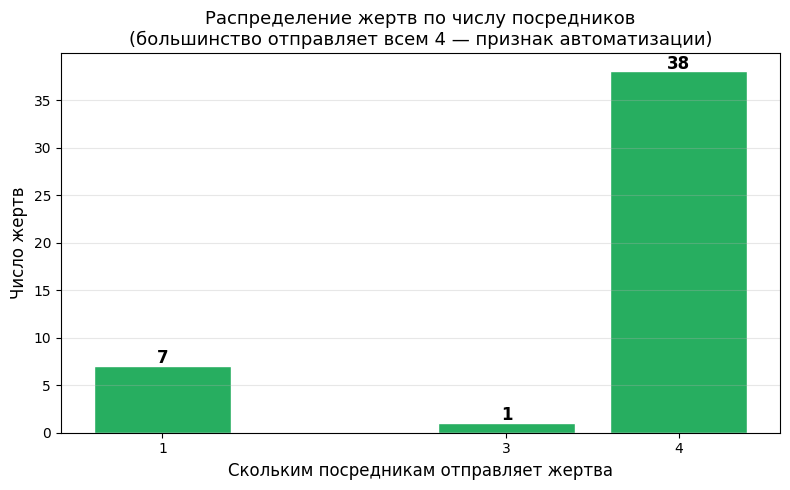

In [40]:
# Число посредников у каждой жертвы
fig, ax = plt.subplots(figsize=(8, 5))

interm_counts = feeder_stats['intermediaries_count'].value_counts().sort_index()
ax.bar(interm_counts.index, interm_counts.values, color='#27ae60', edgecolor='white')
ax.set_xlabel('Скольким посредникам отправляет жертва', fontsize=12)
ax.set_ylabel('Число жертв', fontsize=12)
ax.set_title('Распределение жертв по числу посредников\n'
             '(большинство отправляет всем 4 — признак автоматизации)',
             fontsize=13)
ax.set_xticks(interm_counts.index)
ax.grid(axis='y', alpha=0.3)

for i, v in enumerate(interm_counts.values):
    ax.text(interm_counts.index[i], v + 0.3, str(v),
            ha='center', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

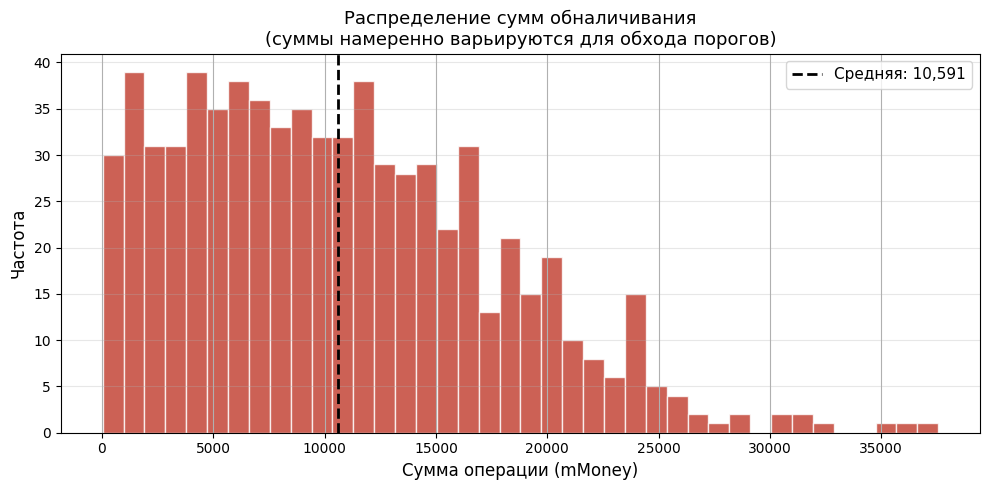

In [41]:
# Распределение сумм операций
fig, ax = plt.subplots(figsize=(10, 5))

main_fraud['amount'].hist(bins=40, color='#c0392b', alpha=0.8,
                           edgecolor='white', ax=ax)
ax.axvline(main_fraud['amount'].mean(), color='black',
           linestyle='--', linewidth=2,
           label=f'Средняя: {main_fraud["amount"].mean():,.0f}')
ax.set_xlabel('Сумма операции (mMoney)', fontsize=12)
ax.set_ylabel('Частота', fontsize=12)
ax.set_title('Распределение сумм обналичивания\n'
             '(суммы намеренно варьируются для обхода порогов)',
             fontsize=13)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

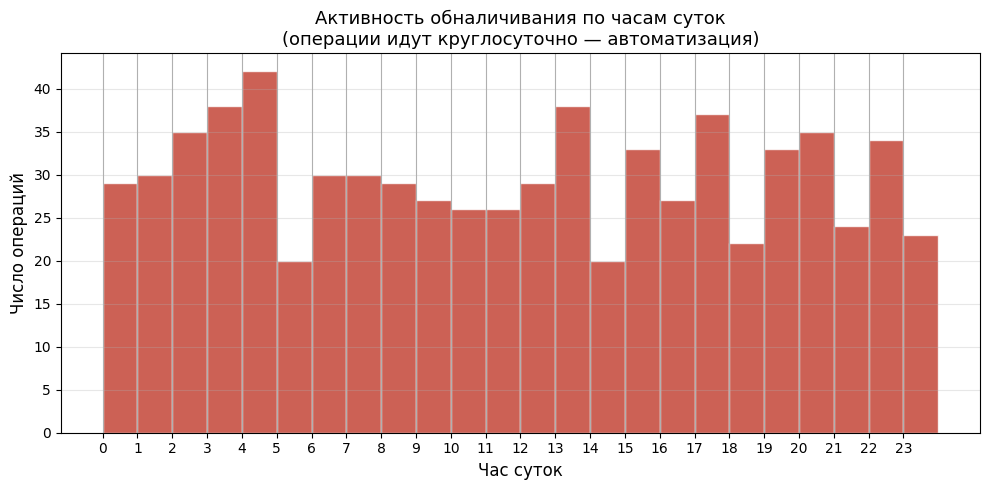

In [42]:
# Активность посредников по часам суток
fig, ax = plt.subplots(figsize=(10, 5))

hours = main_fraud['ts_tx'].dt.hour
hours.hist(bins=24, range=(0, 24), color='#c0392b', alpha=0.8,
           edgecolor='white', ax=ax)
ax.set_xlabel('Час суток', fontsize=12)
ax.set_ylabel('Число операций', fontsize=12)
ax.set_title('Активность обналичивания по часам суток\n'
             '(операции идут круглосуточно — автоматизация)',
             fontsize=13)
ax.set_xticks(range(0, 24))
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()